In [36]:
from sklearn.datasets import fetch_openml

bike_sharing = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
df = bike_sharing.frame

In [37]:
df

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,spring,1,12,19,False,1,True,misty,10.66,12.880,0.60,11.0014,119
17375,spring,1,12,20,False,1,True,misty,10.66,12.880,0.60,11.0014,89
17376,spring,1,12,21,False,1,True,clear,10.66,12.880,0.60,11.0014,90
17377,spring,1,12,22,False,1,True,clear,10.66,13.635,0.56,8.9981,61


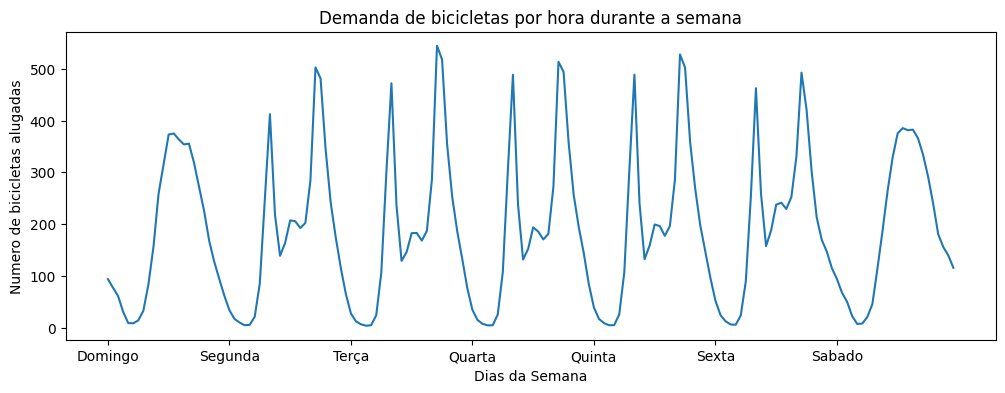

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
average_week_demand = df.groupby(["weekday", "hour"])["count"].mean()
average_week_demand.plot(ax=ax)
_ = ax.set(
    title="Demanda de bicicletas por hora durante a semana",
    xticks=[i * 24 for i in range(7)],
    xticklabels=["Domingo", "Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sabado"],
    xlabel="Dias da Semana",
    ylabel="Numero de bicicletas alugadas",
)

In [39]:
df["count"].max()

977

In [40]:
y = df["count"] / df["count"].max()

In [41]:
y

,count
0,0.016377
1,0.040942
2,0.032753
3,0.013306
4,0.001024
...,...
17374,0.121801
17375,0.091095
17376,0.092119
17377,0.062436


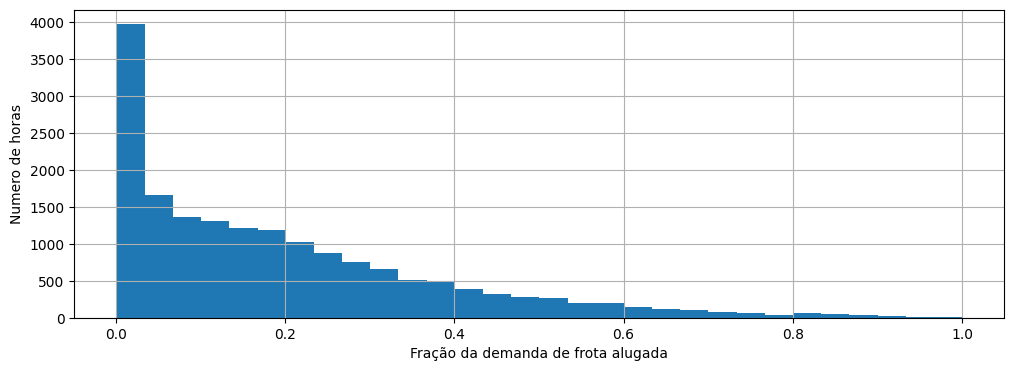

In [42]:
fig, ax = plt.subplots(figsize=(12, 4))
y.hist(bins=30, ax=ax)
_ = ax.set(
    xlabel="Fração da demanda de frota alugada",
    ylabel="Numero de horas",
)


In [43]:
X = df.drop("count", axis="columns")
X

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,spring,1,12,19,False,1,True,misty,10.66,12.880,0.60,11.0014
17375,spring,1,12,20,False,1,True,misty,10.66,12.880,0.60,11.0014
17376,spring,1,12,21,False,1,True,clear,10.66,12.880,0.60,11.0014
17377,spring,1,12,22,False,1,True,clear,10.66,13.635,0.56,8.9981


In [44]:
X["weather"].value_counts()

,count
weather,
clear,11413
misty,4544
rain,1419
heavy_rain,3


In [45]:
X["weather"] = (
    X["weather"]
    .astype(object)
    .replace(to_replace="heavy_rain", value="rain")
    .astype("category")
)

X

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,spring,1,12,19,False,1,True,misty,10.66,12.880,0.60,11.0014
17375,spring,1,12,20,False,1,True,misty,10.66,12.880,0.60,11.0014
17376,spring,1,12,21,False,1,True,clear,10.66,12.880,0.60,11.0014
17377,spring,1,12,22,False,1,True,clear,10.66,13.635,0.56,8.9981


In [46]:
X["weather"].value_counts()

,count
weather,
clear,11413
misty,4544
rain,1422


In [47]:
X["season"].value_counts()

,count
season,
fall,4496
summer,4409
spring,4242
winter,4232


In [48]:
from sklearn.model_selection import TimeSeriesSplit

ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,
    max_train_size=10000,
    test_size=1000,
)

In [49]:
ts_cv

TimeSeriesSplit(gap=48, max_train_size=10000, n_splits=5, test_size=1000)

In [50]:
all_splits = list(ts_cv.split(X, y))
train_0, test_0 = all_splits[0]
X.iloc[test_0]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
12379,summer,1,6,0,False,2,True,clear,22.14,25.760,0.68,27.9993
12380,summer,1,6,1,False,2,True,misty,21.32,25.000,0.77,22.0028
12381,summer,1,6,2,False,2,True,rain,21.32,25.000,0.72,19.9995
12382,summer,1,6,3,False,2,True,rain,20.50,24.240,0.82,12.9980
12383,summer,1,6,4,False,2,True,rain,20.50,24.240,0.82,12.9980
...,...,...,...,...,...,...,...,...,...,...,...,...
13374,fall,1,7,11,False,1,True,clear,34.44,40.150,0.53,15.0013
13375,fall,1,7,12,False,1,True,clear,34.44,39.395,0.49,8.9981
13376,fall,1,7,13,False,1,True,clear,34.44,39.395,0.49,19.0012
13377,fall,1,7,14,False,1,True,clear,36.08,40.910,0.42,7.0015


In [51]:
X.iloc[train_0]

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
2331,summer,0,4,1,False,2,True,misty,25.42,31.060,0.50,6.0032
2332,summer,0,4,2,False,2,True,misty,24.60,31.060,0.53,8.9981
2333,summer,0,4,3,False,2,True,misty,23.78,27.275,0.56,8.9981
2334,summer,0,4,4,False,2,True,misty,22.96,26.515,0.64,8.9981
2335,summer,0,4,5,False,2,True,misty,22.14,25.760,0.68,8.9981
...,...,...,...,...,...,...,...,...,...,...,...,...
12326,summer,1,6,19,False,6,False,clear,26.24,31.060,0.36,11.0014
12327,summer,1,6,20,False,6,False,clear,25.42,31.060,0.35,19.0012
12328,summer,1,6,21,False,6,False,clear,24.60,31.060,0.40,7.0015
12329,summer,1,6,22,False,6,False,clear,23.78,27.275,0.46,8.9981


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
import numpy as np

# Identificar colunas categóricas
categorical_columns = X.columns[X.dtypes == "category"]
numerical_columns = X.columns[X.dtypes != "category"]
print("Categorical features:", categorical_columns.tolist())
print("Numerical features:", numerical_columns.tolist())

# Criar preprocessador com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(drop="if_binary", sparse_output=False), categorical_columns),
    ]
)

Categorical features: ['season', 'holiday', 'workingday', 'weather']
Numerical features: ['year', 'month', 'hour', 'weekday', 'temp', 'feel_temp', 'humidity', 'windspeed']


In [53]:
# Criar rede neural MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(10, 5),  # Duas camadas ocultas: 100 e 50 neurônios
    activation="relu",              # Função de ativação ReLU
    solver="adam",                  # Otimizador Adam (bom para dados grandes)
    learning_rate="adaptive",       # Taxa de aprendizado adaptativa
    max_iter=500,                   # Número máximo de iterações
    early_stopping=True,            # Parar mais cedo se não melhorar
    validation_fraction=0.1,        # 10% dos dados para validação
    random_state=42
)


In [54]:
mlp

MLPRegressor(early_stopping=True, hidden_layer_sizes=(10, 5),
             learning_rate='adaptive', max_iter=500, random_state=42)

In [55]:
# Criar pipeline: preprocessador + rede neural
pipeline = make_pipeline(preprocessor, mlp)
pipeline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['year', 'month', 'hour', 'weekday', 'temp', 'feel_temp', 'humidity',
       'windspeed'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  Index(['season', 'holiday', 'workingday', 'weather'], dtype='object'))])),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(10, 5),
                              learning_rate='adaptive', max_iter=500,
                              random_state=42))])

In [56]:
# Realizar validação cruzada
cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=ts_cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True
)

In [57]:
cv_results

{'fit_time': array([7.51407862, 8.49987125, 6.20932031, 6.12854409, 7.10942316]),
 'score_time': array([0.00828123, 0.00886226, 0.01011705, 0.01089525, 0.00845647]),
 'test_score': array([-0.05780434, -0.05568984, -0.05978485, -0.12717812, -0.08008029]),
 'train_score': array([-0.03585171, -0.03750028, -0.0393147 , -0.06375577, -0.03953916])}

In [58]:
mae_teste = -cv_results["test_score"]
mae_teste

array([0.05780434, 0.05568984, 0.05978485, 0.12717812, 0.08008029])

In [59]:
# Exibir resultados
import numpy as np

mae_train = -cv_results['train_score']
mae_test = -cv_results['test_score']

print(f"MAE Treino:  {mae_train.mean():.4f} ± {mae_train.std():.4f}")
print(f"MAE Teste:   {mae_test.mean():.4f} ± {mae_test.std():.4f}")
print(f"Gap (Overfitting): {(mae_test.mean() - mae_train.mean()):.4f}")

MAE Treino:  0.0432 ± 0.0104
MAE Teste:   0.0761 ± 0.0270
Gap (Overfitting): 0.0329
